
# Notebook sinh số liệu và hình ảnh cho báo cáo HOG + SVM / HOG + Random Forest

Notebook này dùng để:
1. Thống kê số lượng dữ liệu train / val / test.
2. Sinh bảng `data_counts.tex`.
3. Trực quan hóa pipeline tiền xử lý + HOG.
4. So sánh trực quan đặc trưng HOG với hai cấu hình **8x2** và **6x3**.
5. Tải 4 model đã huấn luyện trong thư mục `models`.
6. Đánh giá 4 model trên tập test.
7. Sinh bảng `model_comparison.tex` và các hình `model_comparison.png`, `confusion_matrix_best.png`.
8. Sinh ảnh pipeline dự đoán của mô hình tốt nhất.

> **Lưu ý:**
> - Hãy đặt notebook này trong project và chỉnh `BASE_DIR` nếu cần.
> - Sau khi chạy xong, các file phục vụ báo cáo sẽ nằm trong thư mục `report_assets`.


In [1]:

import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings('ignore')

# =========================
# CẤU HÌNH ĐƯỜNG DẪN
# =========================
# Cách 1: giữ nguyên nếu project của bạn nằm đúng đường dẫn này
BASE_DIR = Path(r'E:\Nam_3_HK2\ThiGiac\DoAn\demo')

# Cách 2: nếu muốn dùng thư mục hiện tại thì mở comment dòng dưới và comment dòng trên
# BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'
ASSETS_DIR = BASE_DIR / 'report_assets'
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['Cam', 'Chidan', 'Hieulenh', 'Nguyhiem', 'Phu']
IMAGE_SIZE = (128, 128)
SEED = 42
VAL_SIZE = 0.2

model_files = {
    'HOG_SVM_6x3': MODELS_DIR / 'HOG_SVM_6x3.joblib',
    'HOG_SVM_8x2': MODELS_DIR / 'HOG_SVM_8x2.joblib',
    'HOG_RF_6x3': MODELS_DIR / 'HOG_RandomForest_6x3.joblib',
    'HOG_RF_8x2': MODELS_DIR / 'HOG_RandomForest_8x2.joblib',
}

print('BASE_DIR   :', BASE_DIR)
print('DATA_DIR   :', DATA_DIR)
print('MODELS_DIR :', MODELS_DIR)
print('ASSETS_DIR :', ASSETS_DIR)
print('\nKiểm tra thư mục tồn tại:')
print('- data  :', DATA_DIR.exists())
print('- models:', MODELS_DIR.exists())


BASE_DIR   : E:\Nam_3_HK2\ThiGiac\DoAn\demo
DATA_DIR   : E:\Nam_3_HK2\ThiGiac\DoAn\demo\data
MODELS_DIR : E:\Nam_3_HK2\ThiGiac\DoAn\demo\models
ASSETS_DIR : E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets

Kiểm tra thư mục tồn tại:
- data  : True
- models: True


## 1. Các hàm hỗ trợ

In [2]:

def list_image_files(folder: Path):
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob('*') if p.suffix.lower() in exts])


def load_gray_resized(img_path: Path, image_size=IMAGE_SIZE):
    img = imread(img_path)
    if img.ndim == 3:
        gray = rgb2gray(img)
    else:
        gray = img.astype(np.float32)
        if gray.max() > 1:
            gray = gray / 255.0

    resized = resize(gray, image_size, anti_aliasing=True)
    return img, gray, resized


def extract_hog_feature(gray_resized, hog_params):
    fd = hog(gray_resized, visualize=False, **hog_params)
    return fd


def extract_hog_visual(gray_resized, hog_params):
    fd, hog_img = hog(gray_resized, visualize=True, **hog_params)
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    return fd, hog_img


def find_any_sample(class_name='Nguyhiem'):
    candidates = list_image_files(DATA_DIR / 'test' / class_name)
    if len(candidates) == 0:
        for cls in CLASSES:
            candidates = list_image_files(DATA_DIR / 'test' / cls)
            if len(candidates) > 0:
                break
    if len(candidates) == 0:
        raise FileNotFoundError('Không tìm thấy ảnh mẫu trong thư mục data/test.')
    return candidates[0]


def save_text(path: Path, text: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        f.write(text)


def format_model_display_name(name: str):
    return name.replace('_', ' ')


hog_params_8x2 = {
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys',
    'feature_vector': True,
}

hog_params_6x3 = {
    'orientations': 9,
    'pixels_per_cell': (6, 6),
    'cells_per_block': (3, 3),
    'block_norm': 'L2-Hys',
    'feature_vector': True,
}


## 2. Thống kê dữ liệu train / val / test

In [3]:

# Đếm số lượng ảnh trong tập train gốc và test
train_full_counts = {}
test_counts = {}

all_train_paths = []
all_train_labels = []

for cls in CLASSES:
    train_cls_paths = list_image_files(DATA_DIR / 'train' / cls)
    test_cls_paths = list_image_files(DATA_DIR / 'test' / cls)

    train_full_counts[cls] = len(train_cls_paths)
    test_counts[cls] = len(test_cls_paths)

    all_train_paths.extend(train_cls_paths)
    all_train_labels.extend([cls] * len(train_cls_paths))

# Chia train / val từ train gốc theo tỉ lệ 8/2, stratify, random_state=42
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths,
    all_train_labels,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=all_train_labels,
)

train_counts = {cls: 0 for cls in CLASSES}
val_counts = {cls: 0 for cls in CLASSES}

for y in train_labels:
    train_counts[y] += 1
for y in val_labels:
    val_counts[y] += 1

stats = []
for cls in CLASSES:
    stats.append({
        'Lớp': cls,
        'Train': train_counts[cls],
        'Validation': val_counts[cls],
        'Test': test_counts[cls],
        'Tổng': train_counts[cls] + val_counts[cls] + test_counts[cls]
    })

stats_df = pd.DataFrame(stats)
stats_df.loc[len(stats_df)] = {
    'Lớp': 'Tổng cộng',
    'Train': stats_df['Train'].sum(),
    'Validation': stats_df['Validation'].sum(),
    'Test': stats_df['Test'].sum(),
    'Tổng': stats_df['Tổng'].sum()
}

print(stats_df)

# Xuất LaTeX table
latex_table = stats_df.to_latex(index=False, escape=False)
save_text(ASSETS_DIR / 'data_counts.tex', latex_table)
print(f'\nĐã lưu: {ASSETS_DIR / "data_counts.tex"}')


         Lớp  Train  Validation  Test  Tổng
0        Cam    556         139    36   731
1     Chidan    522         131    36   689
2   Hieulenh    509         127    31   667
3   Nguyhiem    510         128    29   667
4        Phu    317          79    23   419
5  Tổng cộng   2414         604   155  3173

Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\data_counts.tex


## 3. Trực quan hóa HOG: pipeline đầy đủ và hình so sánh 8x2 vs 6x3

Ảnh mẫu sử dụng: E:\Nam_3_HK2\ThiGiac\DoAn\demo\data\test\Nguyhiem\Nguyhiem_1.jpg


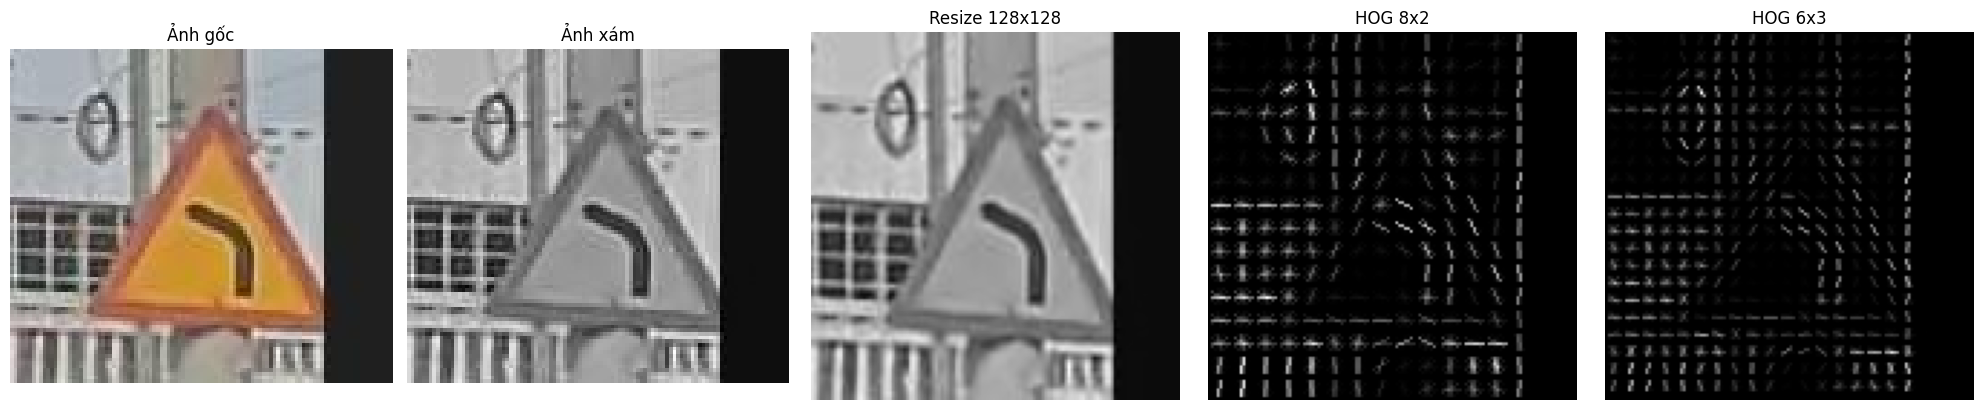

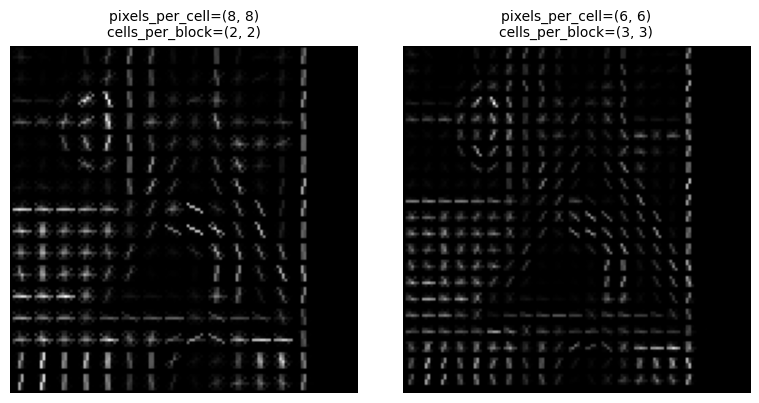

  Cấu hình HOG  orientations pixels_per_cell cells_per_block  \
0      HOG 8x2             9          (8, 8)          (2, 2)   
1      HOG 6x3             9          (6, 6)          (3, 3)   

   Số chiều đặc trưng  
0                8100  
1               29241  

Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\prediction_pipeline_HOG_compare.png
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\hog_feature_compare.png
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\hog_feature_dimensions.tex


In [4]:

def visualize_hog_comparison(sample_path, save_path_pipeline, save_path_compare, save_path_dimensions):
    img, gray, resized = load_gray_resized(sample_path, IMAGE_SIZE)

    fd_8x2, hog_img_8x2 = extract_hog_visual(resized, hog_params_8x2)
    fd_6x3, hog_img_6x3 = extract_hog_visual(resized, hog_params_6x3)

    # ===== Hình 1: pipeline đầy đủ =====
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(img)
    axes[0].set_title('Ảnh gốc')

    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title('Ảnh xám')

    axes[2].imshow(resized, cmap='gray')
    axes[2].set_title('Resize 128x128')

    axes[3].imshow(hog_img_8x2, cmap='gray')
    axes[3].set_title('HOG 8x2')

    axes[4].imshow(hog_img_6x3, cmap='gray')
    axes[4].set_title('HOG 6x3')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_path_pipeline, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # ===== Hình 2: chỉ so sánh 2 ảnh HOG =====
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(hog_img_8x2, cmap='gray')
    axes[0].set_title('pixels_per_cell=(8, 8)\ncells_per_block=(2, 2)', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(hog_img_6x3, cmap='gray')
    axes[1].set_title('pixels_per_cell=(6, 6)\ncells_per_block=(3, 3)', fontsize=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(save_path_compare, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # ===== Bảng số chiều vector đặc trưng =====
    dim_df = pd.DataFrame([
        {
            'Cấu hình HOG': 'HOG 8x2',
            'orientations': 9,
            'pixels_per_cell': '(8, 8)',
            'cells_per_block': '(2, 2)',
            'Số chiều đặc trưng': len(fd_8x2),
        },
        {
            'Cấu hình HOG': 'HOG 6x3',
            'orientations': 9,
            'pixels_per_cell': '(6, 6)',
            'cells_per_block': '(3, 3)',
            'Số chiều đặc trưng': len(fd_6x3),
        },
    ])

    print(dim_df)
    save_text(save_path_dimensions, dim_df.to_latex(index=False, escape=False))
    print(f'\nĐã lưu: {save_path_pipeline}')
    print(f'Đã lưu: {save_path_compare}')
    print(f'Đã lưu: {save_path_dimensions}')


sample_img = find_any_sample('Nguyhiem')
print('Ảnh mẫu sử dụng:', sample_img)

visualize_hog_comparison(
    sample_img,
    ASSETS_DIR / 'prediction_pipeline_HOG_compare.png',
    ASSETS_DIR / 'hog_feature_compare.png',
    ASSETS_DIR / 'hog_feature_dimensions.tex'
)


## 4. Đánh giá 4 model trên tập test

In [5]:

def load_model_payload(model_path: Path):
    payload = joblib.load(model_path)

    # Nếu file lưu là dict chứa nhiều thành phần
    if isinstance(payload, dict):
        model = payload.get('model', None)
        label_encoder = payload.get('label_encoder', None)
        hog_params = payload.get('hog_params', None)
        return payload, model, label_encoder, hog_params

    # Nếu file chỉ lưu thẳng model
    return payload, payload, None, None


results = []
best_model_data = None
best_acc = -1
classification_reports = {}

# Cache tập test để tránh đọc lại nhiều lần
cached_test_images = []
for cls in CLASSES:
    for img_path in list_image_files(DATA_DIR / 'test' / cls):
        _, _, resized = load_gray_resized(img_path, IMAGE_SIZE)
        cached_test_images.append((img_path, cls, resized))

print(f'Số lượng ảnh test dùng để đánh giá: {len(cached_test_images)}')

for model_name, model_path in model_files.items():
    print('\n' + '=' * 80)
    print(f'Đang đánh giá: {model_name}')

    if not model_path.exists():
        print(f'Không tìm thấy file model: {model_path}')
        continue

    payload, model, label_encoder, model_hog_params = load_model_payload(model_path)

    # Nếu model không lưu hog_params thì suy ra từ tên file
    if model_hog_params is None:
        if '6x3' in model_name:
            model_hog_params = hog_params_6x3
        else:
            model_hog_params = hog_params_8x2

    X_test = []
    y_test = []

    for img_path, cls, resized in cached_test_images:
        feat = extract_hog_feature(resized, model_hog_params)
        X_test.append(feat)
        y_test.append(cls)

    X_test = np.array(X_test)

    # Nếu có label encoder thì dùng encoder của model
    if label_encoder is not None:
        y_true = label_encoder.transform(y_test)
        class_names = list(label_encoder.classes_)
    else:
        # Dự phòng: encode theo thứ tự CLASSES
        class_names = CLASSES
        mapping = {c: i for i, c in enumerate(class_names)}
        y_true = np.array([mapping[c] for c in y_test])

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)

    classification_reports[model_name] = report_text
    print(report_text)

    save_text(ASSETS_DIR / f'classification_report_{model_name}.txt', report_text)

    results.append({
        'Mô hình': format_model_display_name(model_name),
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4),
    })

    if acc > best_acc:
        best_acc = acc
        best_model_data = {
            'name': model_name,
            'model': model,
            'label_encoder': label_encoder,
            'hog_params': model_hog_params,
            'class_names': class_names,
            'y_true': y_true,
            'y_pred': y_pred,
            'test_labels_text': y_test,
        }

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print('\nBảng tổng hợp kết quả:')
print(results_df)

save_text(ASSETS_DIR / 'model_comparison.tex', results_df.to_latex(index=False, escape=False))
print(f'\nĐã lưu: {ASSETS_DIR / "model_comparison.tex"}')


Số lượng ảnh test dùng để đánh giá: 155

Đang đánh giá: HOG_SVM_6x3
              precision    recall  f1-score   support

         Cam     0.8421    0.8889    0.8649        36
      Chidan     0.7500    0.7500    0.7500        36
    Hieulenh     0.6774    0.6774    0.6774        31
    Nguyhiem     1.0000    1.0000    1.0000        29
         Phu     0.6190    0.5652    0.5909        23

    accuracy                         0.7871       155
   macro avg     0.7777    0.7763    0.7766       155
weighted avg     0.7842    0.7871    0.7853       155


Đang đánh giá: HOG_SVM_8x2
              precision    recall  f1-score   support

         Cam     0.8462    0.9167    0.8800        36
      Chidan     0.7353    0.6944    0.7143        36
    Hieulenh     0.6774    0.6774    0.6774        31
    Nguyhiem     1.0000    1.0000    1.0000        29
         Phu     0.5455    0.5217    0.5333        23

    accuracy                         0.7742       155
   macro avg     0.7609    0.7621  

## 5. Vẽ biểu đồ so sánh và confusion matrix của mô hình tốt nhất

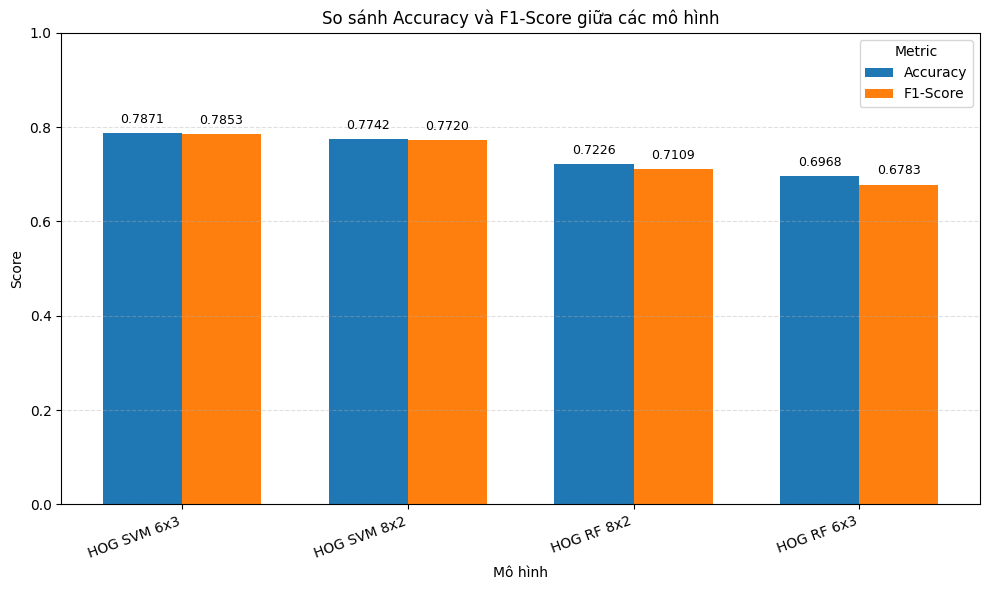

Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\model_comparison.png


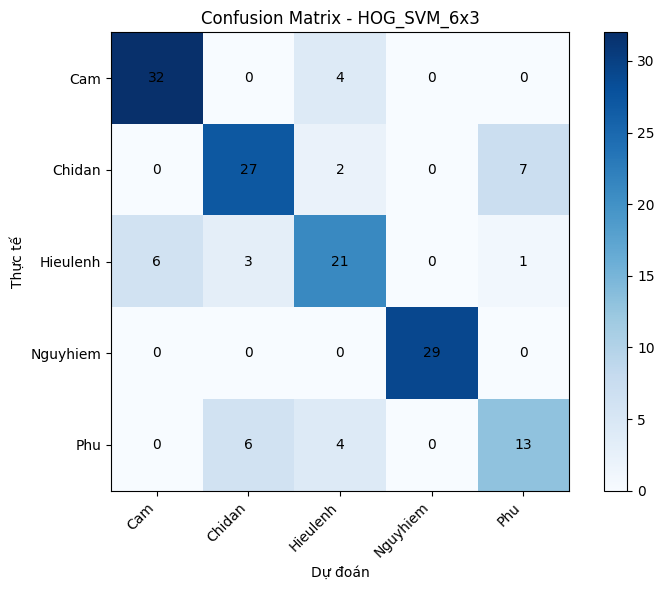

Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\confusion_matrix_best.png
Mô hình tốt nhất hiện tại: HOG_SVM_6x3 | Accuracy = 0.7871


In [6]:
# ===== Biểu đồ cột so sánh =====
if len(results_df) > 0:
    x = np.arange(len(results_df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    bars_acc = ax.bar(
        x - width / 2,
        results_df['Accuracy'],
        width=width,
        label='Accuracy'
    )

    bars_f1 = ax.bar(
        x + width / 2,
        results_df['F1-Score'],
        width=width,
        label='F1-Score'
    )

    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Mô hình'], rotation=20, ha='right')

    # Sửa lỗi biểu đồ bị trống:
    # Không đặt ylim từ 0.8 vì các score hiện tại có mô hình thấp hơn 0.8.
    # Đặt từ 0 đến 1 để phù hợp với thang đo Accuracy/F1-score.
    ax.set_ylim(0, 1.0)

    ax.set_ylabel('Score')
    ax.set_xlabel('Mô hình')
    ax.set_title('So sánh Accuracy và F1-Score giữa các mô hình')
    ax.legend(title='Metric')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Hiển thị giá trị trên đầu từng cột
    for bars in [bars_acc, bars_f1]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.015,
                f'{height:.4f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.tight_layout()
    plt.savefig(ASSETS_DIR / 'model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Đã lưu: {ASSETS_DIR / "model_comparison.png"}')
else:
    print('Không có kết quả mô hình để vẽ biểu đồ.')


# ===== Confusion matrix cho mô hình tốt nhất =====
if best_model_data is not None:
    cm = confusion_matrix(best_model_data['y_true'], best_model_data['y_pred'])
    class_names = best_model_data['class_names']

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')
    ax.set_title(f'Confusion Matrix - {best_model_data["name"]}')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

    plt.tight_layout()
    plt.savefig(ASSETS_DIR / 'confusion_matrix_best.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Đã lưu: {ASSETS_DIR / "confusion_matrix_best.png"}')
    print(f'Mô hình tốt nhất hiện tại: {best_model_data["name"]} | Accuracy = {best_acc:.4f}')
else:
    print('Chưa có mô hình tốt nhất để vẽ confusion matrix.')



## 6. Sinh ảnh pipeline dự đoán cho mô hình tốt nhất

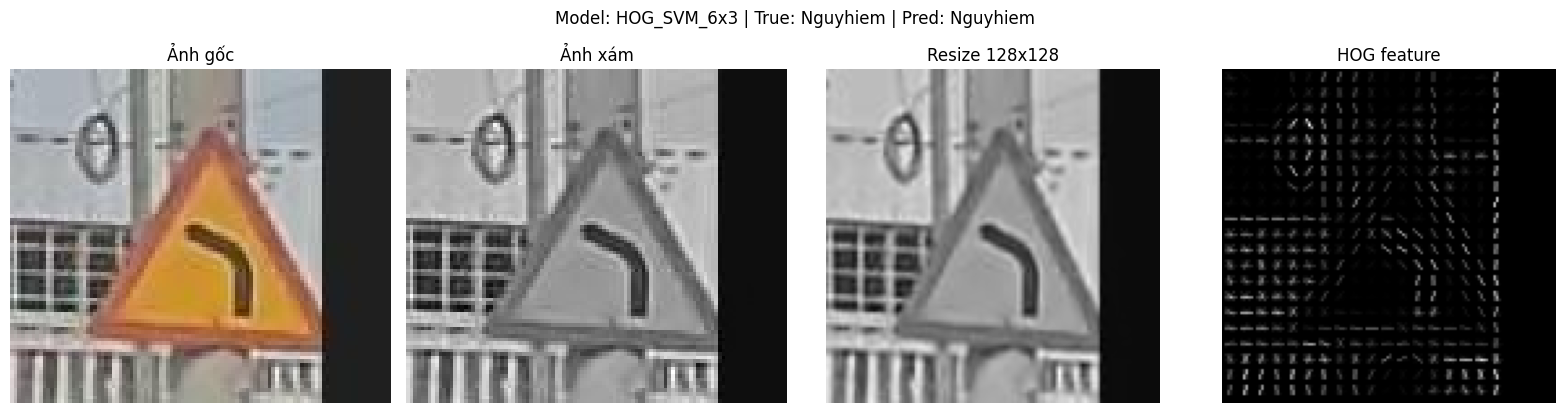

Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\prediction_pipeline_HOG_SVM_6x3.png
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\prediction_pipeline_best.png


In [7]:

def create_prediction_pipeline_for_best(best_model_data, save_dir: Path):
    if best_model_data is None:
        print('Không có best_model_data.')
        return

    best_name = best_model_data['name']
    best_model = best_model_data['model']
    best_le = best_model_data['label_encoder']
    best_hog_params = best_model_data['hog_params']

    # Chọn 1 ảnh test bất kỳ
    sample_path = find_any_sample('Nguyhiem')
    img, gray, resized = load_gray_resized(sample_path, IMAGE_SIZE)

    feat, hog_img = extract_hog_visual(resized, best_hog_params)
    feat = feat.reshape(1, -1)
    pred_idx = best_model.predict(feat)[0]

    if best_le is not None:
        pred_label = best_le.inverse_transform([pred_idx])[0]
    else:
        pred_label = CLASSES[int(pred_idx)] if isinstance(pred_idx, (int, np.integer)) else str(pred_idx)

    true_label = sample_path.parent.name

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img)
    axes[0].set_title('Ảnh gốc')
    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title('Ảnh xám')
    axes[2].imshow(resized, cmap='gray')
    axes[2].set_title('Resize 128x128')
    axes[3].imshow(hog_img, cmap='gray')
    axes[3].set_title('HOG feature')

    for ax in axes:
        ax.axis('off')

    fig.suptitle(
        f'Model: {best_name} | True: {true_label} | Pred: {pred_label}',
        fontsize=12,
        y=1.02
    )

    plt.tight_layout()
    specific_path = save_dir / f'prediction_pipeline_{best_name}.png'
    generic_path = save_dir / 'prediction_pipeline_best.png'
    plt.savefig(specific_path, dpi=300, bbox_inches='tight')
    plt.savefig(generic_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Đã lưu: {specific_path}')
    print(f'Đã lưu: {generic_path}')


create_prediction_pipeline_for_best(best_model_data, ASSETS_DIR)


## 7. Tóm tắt nhanh các file đã sinh

In [8]:

files = sorted([p.name for p in ASSETS_DIR.glob('*')])
print('Các file hiện có trong report_assets:')
for f in files:
    print('-', f)


Các file hiện có trong report_assets:
- classification_report_HOG_RF_6x3.txt
- classification_report_HOG_RF_8x2.txt
- classification_report_HOG_SVM_6x3.txt
- classification_report_HOG_SVM_8x2.txt
- confusion_matrix_best.png
- data_counts.tex
- hog_feature_compare.png
- hog_feature_dimensions.tex
- model_comparison.png
- model_comparison.tex
- prediction_pipeline_HOG_SVM_6x3.png
- prediction_pipeline_HOG_compare.png
- prediction_pipeline_best.png
